# Merlin UK Opportunity Scoring

This notebook creates the Layer 2 opportunity scoring and attraction alignment output for the Merlin UK geographic customer opportunity prototype.

It uses:

- Layer 1 MSOA customer segments from `notebooks/3_clustering.ipynb`
- Public demographic features carried through the segment output
- Curated Merlin attraction metadata from `data/processed/merlin_attraction_data.csv`

## 1. Setup

Define file paths, scoring weights, and shared helper functions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_OUTPUT_DIR = PROJECT_ROOT / "data" / "output"
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEGMENT_INPUT_PATH = DATA_PROCESSED_DIR / "msoa_layer_1_customer_segments.csv"
ATTRACTION_INPUT_PATH = DATA_PROCESSED_DIR / "merlin_attraction_data.csv"

OPPORTUNITY_OUTPUT_PATH = DATA_OUTPUT_DIR / "msoa_layer_2_opportunity_scores.csv"
KEY_RECOMMENDATION_OUTPUT_PATH = DATA_OUTPUT_DIR / "merlin_key_recommendation_output.csv"

SCORING_WEIGHTS = {
    "market_size_score": 0.40,
    "segment_priority_score": 0.30,
    "recommended_attraction_alignment_score": 0.30,
}
assert abs(sum(SCORING_WEIGHTS.values()) - 1.0) < 1e-9

PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]

ATTRACTION_ACCESSIBILITY_DECAY_MILES = 50
ANNUAL_PASS_DISTANCE_MILES = 30
CLUSTER_MARKETING_DISTANCE_MILES = 30
CLUSTER_MARKETING_MIN_ATTRACTIONS = 2
SHORT_BREAK_MIN_DISTANCE_MILES = 40
SHORT_BREAK_MAX_DISTANCE_MILES = 110


def percentile_score(series, ascending=True):
    return series.rank(pct=True, ascending=ascending, method="average").astype(float)


def clipped_01(series):
    return pd.Series(series).clip(lower=0, upper=1).astype(float)


def haversine_miles(lat1, lon1, lat2, lon2):
    earth_radius_miles = 3958.7613
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * earth_radius_miles * np.arcsin(np.sqrt(a))


## 2. Load Inputs and QA

Load the Layer 1 segment output and Merlin attraction data. The MSOA file already includes segment labels and the raw count variables needed for opportunity scoring.

In [2]:
msoa = pd.read_csv(SEGMENT_INPUT_PATH, dtype={"geo_code": str})
attractions = pd.read_csv(ATTRACTION_INPUT_PATH, encoding="utf-8-sig")

print(f"MSOAs: {msoa.shape[0]:,} rows x {msoa.shape[1]:,} columns")
print(f"Attractions: {attractions.shape[0]:,} rows x {attractions.shape[1]:,} columns")

display(msoa.head())
display(attractions)

MSOAs: 7,264 rows x 28 columns
Attractions: 20 rows x 11 columns


,geo_code,geo_name,country,latitude,longitude,segment_id,segment_label,total_population,children_count_0_14,young_adult_count_15_24,core_family_adult_count_25_44,midlife_adult_count_45_64,older_adult_count_65_plus,total_households,households_with_dependent_children,households_deprived,households_not_deprived,households_no_car_or_van,households_with_car_or_van,residents_social_grade_ab_c1,children_share_0_14,young_adult_share_15_24,core_family_adult_share_25_44,midlife_adult_share_45_64,older_adult_share_65_plus,car_access_household_share,population_density_per_sq_km,ab_c1_social_grade_share
0,E02000001,City of London 001,England,51.51562,-0.093490,0,Dense Urban Professional Markets,8580,546,1181,3488,2159,1206,4916,431,1977,2937,3793,1120,5950,0.063636,0.137646,0.406527,0.251632,0.140559,0.227967,2975.0,0.840514
1,E02000002,Barking and Dagenham 001,England,51.58652,0.138756,2,Balanced Regional Family Markets,8286,2172,1028,2426,1731,929,2871,1350,1916,954,914,1956,2971,0.262129,0.124065,0.292783,0.208907,0.112117,0.681533,3831.0,0.410756
2,E02000003,Barking and Dagenham 002,England,51.57606,0.138149,2,Balanced Regional Family Markets,11539,2560,1451,3653,2604,1271,3931,1660,2281,1649,1156,2774,4756,0.221856,0.125747,0.316579,0.225669,0.110148,0.705852,5389.7,0.473847
3,E02000004,Barking and Dagenham 003,England,51.55639,0.176828,4,Mainstream Affluent Suburban Markets,6638,1238,815,1919,1667,999,2309,835,1295,1014,544,1765,2739,0.186502,0.122778,0.289093,0.251130,0.150497,0.764400,2663.6,0.508069
4,E02000005,Barking and Dagenham 004,England,51.56069,0.144267,2,Balanced Regional Family Markets,11082,2935,1355,3503,2406,883,3627,1804,2086,1544,1016,2612,4628,0.264844,0.122270,0.316098,0.217109,0.079679,0.719956,9327.5,0.461278


,attraction_name_official,brand_official,business_division_official,city_official,postcode_official,latitude,longitude,experience_category_inferred,indoor_outdoor_inferred,target_age_group_inferred,family_friendly_inferred
0,Alton Towers Resort,Alton Towers,Resort Theme Parks,Alton,ST10 4DB,52.985926,-1.887592,Thrill Theme Park,Mixed,children_0_14|young_adults_15_24|core_family_adults_25_44,Yes
1,Thorpe Park,Thorpe Park,Resort Theme Parks,Chertsey,KT16 8PN,51.405100,-0.532991,Thrill Theme Park,Outdoor,young_adults_15_24|core_family_adults_25_44,Yes
2,Chessington World of Adventures Resort,Chessington,Resort Theme Parks,Chessington,KT9 2NE,51.348502,-0.321584,Family Theme Park,Mixed,children_0_14|core_family_adults_25_44,Yes
3,LEGOLAND Windsor Resort,LEGOLAND,Resort Theme Parks,Windsor,SL4 4AY,51.463834,-0.652602,Family Theme Park,Outdoor,children_0_14|core_family_adults_25_44,Yes
4,Warwick Castle,Warwick Castle,Gateway Attractions,Warwick,CV34 6AU,52.279500,-1.584900,Heritage Attraction,Mixed,children_0_14|core_family_adults_25_44|midlife_adults_45_64,Yes
5,London Eye,London Eye,Gateway Attractions,London,SE1 7PB,51.503186,-0.122094,Urban Icon Attraction,Outdoor,all_age_groups,Yes
6,Madame Tussauds London,Madame Tussauds,Gateway Attractions,London,NW1 5LR,51.523005,-0.156988,Urban Icon Attraction,Indoor,all_age_groups,Yes
7,London Dungeon,The Dungeons,Gateway Attractions,London,SE1 7PB,51.502512,-0.121338,Young Adult Immersive,Indoor,young_adults_15_24|core_family_adults_25_44,No
8,Shrek's Adventure! London,Shrek's Adventure!,Gateway Attractions,London,SE1 7PB,51.501882,-0.121948,Family Discovery Attraction,Indoor,children_0_14|core_family_adults_25_44,Yes
9,Cadbury World,Cadbury World,Gateway Attractions,Birmingham,B30 1JR,52.428795,-1.934000,Family Discovery Attraction,Indoor,children_0_14|core_family_adults_25_44|midlife_adults_45_64,Yes


### 2.1 Check missing values

In [3]:
required_msoa_columns = [
    "geo_code", "geo_name", "country", "latitude", "longitude", "segment_id", "segment_label",
    "total_population", "children_count_0_14", "young_adult_count_15_24",
    "core_family_adult_count_25_44", "midlife_adult_count_45_64", "older_adult_count_65_plus",
    "total_households", "households_with_dependent_children", "households_deprived",
    "households_no_car_or_van", "households_with_car_or_van", "residents_social_grade_ab_c1",
    "children_share_0_14", "young_adult_share_15_24", "core_family_adult_share_25_44",
    "midlife_adult_share_45_64", "older_adult_share_65_plus", "car_access_household_share",
    "population_density_per_sq_km", "ab_c1_social_grade_share",
]
required_attraction_columns = [
    "attraction_name_official", "brand_official", "business_division_official", "city_official",
    "latitude", "longitude", "experience_category_inferred", "target_age_group_inferred",
    "family_friendly_inferred",
]

missing_msoa_columns = sorted(set(required_msoa_columns) - set(msoa.columns))
missing_attraction_columns = sorted(set(required_attraction_columns) - set(attractions.columns))
assert not missing_msoa_columns, f"Missing MSOA columns: {missing_msoa_columns}"
assert not missing_attraction_columns, f"Missing attraction columns: {missing_attraction_columns}"
assert msoa["geo_code"].is_unique, "Each MSOA should appear once."
assert msoa[["latitude", "longitude"]].notna().all().all(), "MSOA latitude/longitude cannot be missing."
assert attractions[["latitude", "longitude"]].notna().all().all(), "Attraction latitude/longitude cannot be missing."

msoa[required_msoa_columns].isna().sum().sort_values(ascending=False).head(10)

geo_code                              0
households_with_dependent_children    0
population_density_per_sq_km          0
car_access_household_share            0
older_adult_share_65_plus             0
midlife_adult_share_45_64             0
core_family_adult_share_25_44         0
young_adult_share_15_24               0
children_share_0_14                   0
residents_social_grade_ab_c1          0
dtype: int64

## 3. Feature Engineering for Scoring

Only two MSOA-level scores are needed before the attraction recommendation step:

- `market_size_score`: MSOA population percentile. Larger MSOAs score higher because they offer more addressable demand.
- `segment_priority_score`: business judgement from the Layer 1 segment interpretation. Higher-priority segments score higher because they better match Merlin's strategic customer opportunity.

Other demographic variables are still kept in the output for context and later analysis, but they are not converted into separate opportunity-score components here.

In [4]:
scored = msoa.copy()

# Keep these descriptive shares for export and interpretation, but do not use them as separate score components.
scored["family_household_share"] = scored["households_with_dependent_children"] / scored["total_households"]
scored["deprived_household_share"] = scored["households_deprived"] / scored["total_households"]
scored["not_deprived_household_share"] = 1 - scored["deprived_household_share"]

scored["market_size_score"] = percentile_score(scored["total_population"])

SEGMENT_PRIORITY = {
    "Mainstream Affluent Suburban Markets": 1.00,
    "Balanced Regional Family Markets": 0.80,
    "Dense Urban Professional Markets": 0.60,
    "Older Rural & Low-Density Markets": 0.40,
    "Student & Young Adult Urban Markets": 0.20,
}
scored["segment_priority_score"] = scored["segment_label"].map(SEGMENT_PRIORITY)
assert scored["segment_priority_score"].notna().all(), "Every segment needs a priority score."

pre_recommendation_score_columns = ["market_size_score", "segment_priority_score"]
scored[pre_recommendation_score_columns].describe().round(3)

,market_size_score,segment_priority_score
count,7264.000,7264.000
mean,0.500,0.750
std,0.289,0.256
min,0.000,0.200
25%,0.250,0.400
50%,0.500,0.800
75%,0.750,1.000
max,1.000,1.000


## 4. Merlin Attraction Distance and Alignment

Distances are straight-line centroid-to-attraction distances. They are suitable for a prototype accessibility signal, but they are not drive times. Distances are reported in **miles**, which is the more familiar unit for UK stakeholder discussion.

### 4.1 Explain the Attraction Alignment Score

The attraction recommendation uses a combined `recommended_attraction_alignment_score`. This score is calculated for every MSOA-attraction pair, then the highest-scoring attraction is selected for that MSOA.

The formula is:

```text
recommended_attraction_alignment_score =
    0.70 * segment_category_fit_score
  + 0.30 * attraction_accessibility
```

The two inputs mean:

- `segment_category_fit_score`: how well the attraction category fits the MSOA's customer segment. This comes from the segment-to-category rule table in section 4.3.
- `attraction_accessibility`: how accessible that specific attraction is from the MSOA centroid. This is calculated from straight-line distance in miles:

```text
attraction_accessibility = exp(-distance_to_that_attraction_miles / 50)
```

The 50-mile decay constant is a simple stakeholder-friendly assumption: accessibility reduces gradually as distance increases, without treating a nearby and slightly farther MSOA as completely different. The 70/30 split means the recommendation is mostly driven by customer/proposition fit, but distance still matters when choosing the most practical attraction. This is not a drive-time model; it is a transparent prototype proxy that should be calibrated with travel-time or catchment data if available.

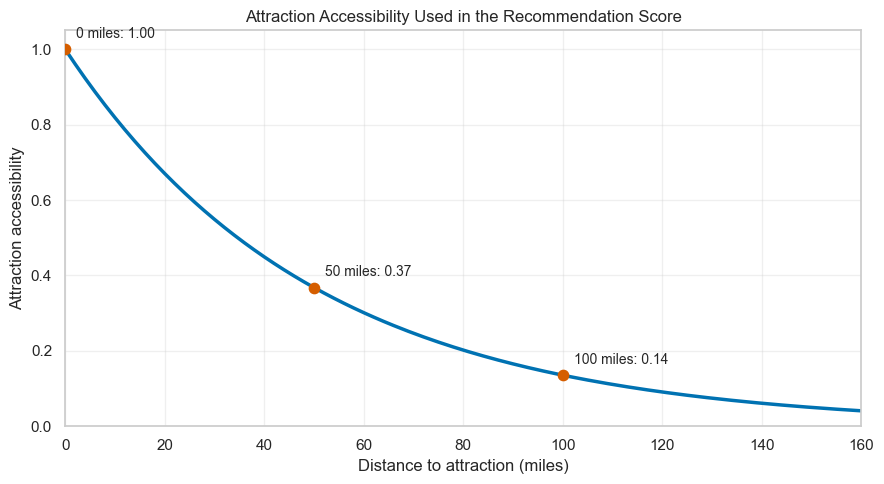

In [5]:
distance_example = pd.DataFrame({"distance_to_attraction_miles": np.linspace(0, 160, 161)})
distance_example["attraction_accessibility"] = np.exp(
    -distance_example["distance_to_attraction_miles"] / ATTRACTION_ACCESSIBILITY_DECAY_MILES
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=distance_example,
    x="distance_to_attraction_miles",
    y="attraction_accessibility",
    color="#0072B2",
    linewidth=2.5,
    ax=ax,
)

reference_distances = [0, round(ATTRACTION_ACCESSIBILITY_DECAY_MILES), round(2 * ATTRACTION_ACCESSIBILITY_DECAY_MILES)]
for distance in reference_distances:
    score = np.exp(-distance / ATTRACTION_ACCESSIBILITY_DECAY_MILES)
    ax.scatter(distance, score, color="#D55E00", s=55, zorder=3)
    ax.annotate(
        f"{distance} miles: {score:.2f}",
        xy=(distance, score),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
    )

ax.set_title("Attraction Accessibility Used in the Recommendation Score")
ax.set_xlabel("Distance to attraction (miles)")
ax.set_ylabel("Attraction accessibility")
ax.set_xlim(0, 160)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Calculate Nearest Merlin Attraction Distance

Calculate straight-line distances from every MSOA centroid to every Merlin attraction. This creates the distance matrix used later for attraction-specific accessibility. We also keep the nearest Merlin attraction overall as a descriptive field for interpretation.

In [6]:
msoa_lat = scored["latitude"].to_numpy()[:, None]
msoa_lon = scored["longitude"].to_numpy()[:, None]
attr_lat = attractions["latitude"].to_numpy()[None, :]
attr_lon = attractions["longitude"].to_numpy()[None, :]

distance_matrix = haversine_miles(msoa_lat, msoa_lon, attr_lat, attr_lon)
nearest_idx = distance_matrix.argmin(axis=1)

scored["nearest_merlin_attraction"] = attractions.iloc[nearest_idx]["attraction_name_official"].to_numpy()
scored["nearest_merlin_brand"] = attractions.iloc[nearest_idx]["brand_official"].to_numpy()
scored["nearest_merlin_category"] = attractions.iloc[nearest_idx]["experience_category_inferred"].to_numpy()
scored["nearest_merlin_distance_miles"] = distance_matrix.min(axis=1).round(1)


scored[["geo_name", "segment_label", "nearest_merlin_attraction", "nearest_merlin_distance_miles"]].head()

,geo_name,segment_label,nearest_merlin_attraction,nearest_merlin_distance_miles
0,City of London 001,Dense Urban Professional Markets,London Eye,1.5
1,Barking and Dagenham 001,Balanced Regional Family Markets,London Dungeon,12.6
2,Barking and Dagenham 002,Balanced Regional Family Markets,London Dungeon,12.3
3,Barking and Dagenham 003,Mainstream Affluent Suburban Markets,London Dungeon,13.3
4,Barking and Dagenham 004,Balanced Regional Family Markets,London Dungeon,12.1


### 4.3 Segment-Based Attraction Fit and Recommendation

This step recommends a specific Merlin attraction for each MSOA using a simple, explainable process. The recommendation is not based on distance alone, and it is not based on demographics alone. It combines the customer segment fit with attraction accessibility.

The process works as follows:

1. **Start with the MSOA segment.** Each MSOA already has a `segment_label` from Layer 1, such as `Mainstream Affluent Suburban Markets`, `Balanced Regional Family Markets`, or `Student & Young Adult Urban Markets`.

2. **Map that segment to Merlin attraction categories.** The table below assigns a `segment_category_fit_score` between each customer segment and each simplified attraction category from `merlin_attraction_data.csv`. A score of `1.00` means the category is a very strong fit for that segment. Lower scores mean the category is still possible, but less central to the segment proposition.

3. **Score every Merlin attraction for that MSOA.** Each attraction inherits the segment/category fit score for its category. For example, if an MSOA is in `Balanced Regional Family Markets`, then attractions in `Family Discovery Attraction` receive a high fit score because that category is a strong family proposition.

4. **Calculate attraction-specific accessibility.** For each MSOA-attraction pair, calculate `attraction_accessibility` from the straight-line distance to that specific attraction using the distance-decay formula in section 4.1.

5. **Combine fit and accessibility.** For each MSOA-attraction pair, calculate `recommended_attraction_alignment_score` using the 70/30 formula in section 4.1.

6. **Pick the highest-scoring attraction.** The attraction with the highest `recommended_attraction_alignment_score` becomes the `recommended_attraction_name` for that MSOA.

The output fields mean:

- `recommended_attraction_name`: the Merlin attraction with the best combined fit and accessibility score.
- `recommended_attraction_category`: the simplified proposition category of that attraction.
- `recommended_attraction_distance_miles`: straight-line distance from the MSOA centroid to the recommended attraction, reported in miles.
- `segment_category_fit_score`: the segment/category fit score of the recommended attraction only.
- `recommended_attraction_alignment_score`: the final combined score used to choose the recommended attraction and to feed into the overall opportunity score.

In short: **the segment decides what kind of Merlin proposition fits; distance helps choose the most practical attraction within that proposition.**

In [7]:
SEGMENT_ATTRACTION_CATEGORY_FIT = {
    "Mainstream Affluent Suburban Markets": {
        "Family Theme Park": 1.00,
        "Family Discovery Attraction": 0.95,
        "Thrill Theme Park": 0.80,
        "Heritage Attraction": 0.75,
        "Urban Icon Attraction": 0.65,
        "Young Adult Immersive": 0.50,
    },
    "Balanced Regional Family Markets": {
        "Family Discovery Attraction": 1.00,
        "Family Theme Park": 0.90,
        "Heritage Attraction": 0.75,
        "Thrill Theme Park": 0.65,
        "Urban Icon Attraction": 0.60,
        "Young Adult Immersive": 0.45,
    },
    "Dense Urban Professional Markets": {
        "Urban Icon Attraction": 1.00,
        "Young Adult Immersive": 0.85,
        "Family Discovery Attraction": 0.75,
        "Thrill Theme Park": 0.65,
        "Heritage Attraction": 0.55,
        "Family Theme Park": 0.50,
    },
    "Student & Young Adult Urban Markets": {
        "Young Adult Immersive": 1.00,
        "Thrill Theme Park": 0.90,
        "Urban Icon Attraction": 0.80,
        "Family Discovery Attraction": 0.55,
        "Family Theme Park": 0.45,
        "Heritage Attraction": 0.35,
    },
    "Older Rural & Low-Density Markets": {
        "Heritage Attraction": 1.00,
        "Family Discovery Attraction": 0.80,
        "Family Theme Park": 0.70,
        "Urban Icon Attraction": 0.55,
        "Thrill Theme Park": 0.45,
        "Young Adult Immersive": 0.30,
    },
}

attraction_categories = attractions["experience_category_inferred"].tolist()
category_fit_matrix = np.array(
    [
        [SEGMENT_ATTRACTION_CATEGORY_FIT[segment].get(category, 0.25) for category in attraction_categories]
        for segment in scored["segment_label"]
    ]
)

attraction_accessibility_matrix = np.clip(np.exp(-distance_matrix / ATTRACTION_ACCESSIBILITY_DECAY_MILES), 0, 1)
alignment_matrix = np.clip(0.70 * category_fit_matrix + 0.30 * attraction_accessibility_matrix, 0, 1)
best_alignment_idx = alignment_matrix.argmax(axis=1)

scored["segment_category_fit_score"] = category_fit_matrix[np.arange(len(scored)), best_alignment_idx]
scored["recommended_attraction_name"] = attractions.iloc[best_alignment_idx]["attraction_name_official"].to_numpy()
scored["recommended_attraction_brand"] = attractions.iloc[best_alignment_idx]["brand_official"].to_numpy()
scored["recommended_attraction_category"] = attractions.iloc[best_alignment_idx]["experience_category_inferred"].to_numpy()
scored["recommended_attraction_distance_miles"] = distance_matrix[np.arange(len(scored)), best_alignment_idx].round(1)
scored["recommended_attraction_alignment_score"] = alignment_matrix.max(axis=1)
scored["recommended_attraction_focus"] = scored["recommended_attraction_brand"] + " - " + scored["recommended_attraction_category"]

segment_category_fit_table = pd.DataFrame(SEGMENT_ATTRACTION_CATEGORY_FIT).T[attractions["experience_category_inferred"].drop_duplicates().sort_values()]
display(segment_category_fit_table)

scored[[
    "geo_name",
    "segment_label",
    "recommended_attraction_name",
    "recommended_attraction_category",
    "recommended_attraction_distance_miles",
    "segment_category_fit_score",
    "recommended_attraction_alignment_score",
]].head()

,Family Discovery Attraction,Family Theme Park,Heritage Attraction,Thrill Theme Park,Urban Icon Attraction,Young Adult Immersive
Mainstream Affluent Suburban Markets,0.95,1.00,0.75,0.80,0.65,0.50
Balanced Regional Family Markets,1.00,0.90,0.75,0.65,0.60,0.45
Dense Urban Professional Markets,0.75,0.50,0.55,0.65,1.00,0.85
Student & Young Adult Urban Markets,0.55,0.45,0.35,0.90,0.80,1.00
Older Rural & Low-Density Markets,0.80,0.70,1.00,0.45,0.55,0.30


,geo_name,segment_label,recommended_attraction_name,recommended_attraction_category,recommended_attraction_distance_miles,segment_category_fit_score,recommended_attraction_alignment_score
0,City of London 001,Dense Urban Professional Markets,London Eye,Urban Icon Attraction,1.5,1.00,0.991132
1,Barking and Dagenham 001,Balanced Regional Family Markets,Shrek's Adventure! London,Family Discovery Attraction,12.6,1.00,0.933001
2,Barking and Dagenham 002,Balanced Regional Family Markets,Shrek's Adventure! London,Family Discovery Attraction,12.3,1.00,0.934592
3,Barking and Dagenham 003,Mainstream Affluent Suburban Markets,Shrek's Adventure! London,Family Discovery Attraction,13.4,0.95,0.894548
4,Barking and Dagenham 004,Balanced Regional Family Markets,Shrek's Adventure! London,Family Discovery Attraction,12.1,1.00,0.935317


## 5. Overall Opportunity Score

The overall score is intentionally simple and presentation-friendly. It combines three signals:

1. **Market scale**: is the local population large enough to matter?
2. **Customer segment priority**: is this the type of market Merlin wants to prioritise?
3. **Merlin proposition alignment**: is there a relevant and reasonably accessible Merlin attraction proposition for this MSOA?

The formula is:

```text
overall_opportunity_score =
    0.40 * market_size_score
  + 0.30 * segment_priority_score
  + 0.30 * recommended_attraction_alignment_score
```

The result is multiplied by 100 so the final score is easier to read on a 0-100 scale. The output is kept as a continuous score, rank and percentile. I do not create separate categorical priority labels because that would introduce an unnecessary second segmentation layer.

### 5.1 Calculate and Review Overall Opportunity Score

In [8]:
score_columns = list(SCORING_WEIGHTS.keys())
scored["overall_opportunity_score"] = 0.0
for column, weight in SCORING_WEIGHTS.items():
    scored["overall_opportunity_score"] += weight * scored[column]

scored["overall_opportunity_score"] = (100 * scored["overall_opportunity_score"]).round(1)
scored["opportunity_rank"] = scored["overall_opportunity_score"].rank(ascending=False, method="first").astype(int)
scored["opportunity_percentile"] = 1 - ((scored["opportunity_rank"] - 1) / (len(scored) - 1))

scored[["overall_opportunity_score", "opportunity_rank", "opportunity_percentile"] + score_columns].describe().round(2)

,overall_opportunity_score,opportunity_rank,opportunity_percentile,market_size_score,segment_priority_score,recommended_attraction_alignment_score
count,7264.0,7264.00,7264.00,7264.00,7264.00,7264.00
mean,67.7,3632.50,0.50,0.50,0.75,0.84
std,15.1,2097.08,0.29,0.29,0.26,0.08
min,29.4,1.00,0.00,0.00,0.20,0.70
25%,57.4,1816.75,0.25,0.25,0.40,0.77
50%,68.3,3632.50,0.50,0.50,0.80,0.83
75%,79.7,5448.25,0.75,0.75,1.00,0.91
max,97.7,7264.00,1.00,1.00,1.00,1.00


### 5.2 Add Activation and Driver Explanations

In [9]:
def key_contributing_driver(row):
    labels = {
        "market_size_score": "large local market",
        "segment_priority_score": "priority customer segment",
        "recommended_attraction_alignment_score": "strong Merlin proposition alignment",
    }
    weighted_contributions = {
        column: row[column] * SCORING_WEIGHTS[column]
        for column in score_columns
    }
    top_component = max(weighted_contributions, key=weighted_contributions.get)
    return labels[top_component]


scored["key_contributing_driver"] = scored.apply(key_contributing_driver, axis=1)
scored["assumptions_flag"] = "Straight-line distance proxy in miles; judgement-based weights; attraction coordinates and simplified categories are maintained in merlin_attraction_data.csv."

scored.sort_values("opportunity_rank").head(10)[[
    "opportunity_rank", "geo_name", "country", "segment_label", "overall_opportunity_score",
    "recommended_attraction_name", "recommended_attraction_distance_miles", "key_contributing_driver",
]]

,opportunity_rank,geo_name,country,segment_label,overall_opportunity_score,recommended_attraction_name,recommended_attraction_distance_miles,key_contributing_driver
3203,1,Bracknell Forest 002,England,Mainstream Affluent Suburban Markets,97.7,LEGOLAND Windsor Resort,5.1,large local market
569,2,Kingston upon Thames 004,England,Mainstream Affluent Suburban Markets,97.6,Chessington World of Adventures Resort,4.8,large local market
6585,3,Epsom and Ewell 010,England,Mainstream Affluent Suburban Markets,97.6,Chessington World of Adventures Resort,3.6,large local market
3298,4,Wokingham 012,England,Mainstream Affluent Suburban Markets,97.5,LEGOLAND Windsor Resort,12.7,large local market
6154,5,Runnymede 007,England,Mainstream Affluent Suburban Markets,97.5,Chessington World of Adventures Resort,8.0,large local market
6628,6,Harrow 033,England,Mainstream Affluent Suburban Markets,97.3,Chessington World of Adventures Resort,16.8,large local market
6668,7,Redbridge 036,England,Mainstream Affluent Suburban Markets,97.3,Shrek's Adventure! London,9.4,large local market
741,8,Richmond upon Thames 004,England,Mainstream Affluent Suburban Markets,97.2,Chessington World of Adventures Resort,8.4,large local market
3529,9,Buckinghamshire 053,England,Mainstream Affluent Suburban Markets,97.1,LEGOLAND Windsor Resort,10.0,large local market
5001,10,Fylde 002,England,Mainstream Affluent Suburban Markets,96.9,SEA LIFE Blackpool,6.7,large local market


### 5.3 Recommended Activation Types

The opportunity score ranks **where** Merlin should focus. This step assigns each MSOA a simple `recommended_activation_type` that explains **how** Merlin could activate that area if it is included in the planning view.

The activation type is assigned for every MSOA, regardless of its opportunity rank. The dashboard's `Top opportunity areas` slider then controls how many MSOAs stakeholders include in the view.

The output deliberately uses a small number of activation types, so it does not become a second segmentation model:

- **Multi-Attraction Cluster Marketing**: MSOAs within 30 miles of at least two distinct Merlin attractions. This supports cross-sell, bundled messaging, and annual-pass propositions across nearby attractions.
- **Annual Pass**: MSOAs within 30 miles of the recommended attraction. This identifies local catchments where repeat visitation and pass value are easiest to communicate.
- **Short Break**: family/affluent MSOAs that are 40-110 miles from the recommended attraction and aligned to resort or destination-style attractions. This uses a simple overnight-trip distance band: far enough for a short break to make sense, but not so far that the journey becomes unrealistic for most households.
- **Other**: MSOAs that do not meet the simple rules for cluster marketing, annual pass, or short-break activation. These areas are still retained, scored and ranked; the label simply means there is no specific strategic activation from this ruleset.

This separation keeps the logic easy to explain: **opportunity rank decides where to prioritise; activation type explains the best route to market for the areas currently selected.**


In [10]:
RESORT_OR_DESTINATION_CATEGORIES = [
    "Family Theme Park",
    "Thrill Theme Park",
    "Heritage Attraction",
]

within_cluster_distance = distance_matrix <= CLUSTER_MARKETING_DISTANCE_MILES
scored["merlin_attractions_within_30_miles"] = within_cluster_distance.sum(axis=1).astype(int)

attraction_names = attractions["attraction_name_official"].to_numpy()
scored["merlin_attraction_cluster_names_30_miles"] = [
    "; ".join(attraction_names[row]) if row.any() else "None within 30 miles"
    for row in within_cluster_distance
]

family_affluent_mask = (
    (scored["family_household_share"] >= scored["family_household_share"].median())
    & (scored["ab_c1_social_grade_share"] >= scored["ab_c1_social_grade_share"].median())
)
resort_or_destination_mask = scored["recommended_attraction_category"].isin(RESORT_OR_DESTINATION_CATEGORIES)

scored["annual_pass_repeat_visit_flag"] = scored["recommended_attraction_distance_miles"] <= ANNUAL_PASS_DISTANCE_MILES
scored["cluster_marketing_flag"] = scored["merlin_attractions_within_30_miles"] >= CLUSTER_MARKETING_MIN_ATTRACTIONS
scored["short_break_opportunity_flag"] = (
    family_affluent_mask
    & resort_or_destination_mask
    & scored["recommended_attraction_distance_miles"].between(SHORT_BREAK_MIN_DISTANCE_MILES, SHORT_BREAK_MAX_DISTANCE_MILES)
)


def recommended_activation_type(row):
    if row["cluster_marketing_flag"]:
        return "Multi-attraction cluster marketing"
    if row["annual_pass_repeat_visit_flag"]:
        return "Annual pass"
    if row["short_break_opportunity_flag"]:
        return "Short break"
    return "Other"


def activation_type_rationale(row):
    if row["recommended_activation_type"] == "Multi-attraction cluster marketing":
        return f"MSOA has {row['merlin_attractions_within_30_miles']} Merlin attractions within 30 miles."
    if row["recommended_activation_type"] == "Annual pass":
        return "MSOA is within 30 miles of the recommended attraction."
    if row["recommended_activation_type"] == "Short break":
        return "Family/affluent MSOA at a practical overnight-trip distance from the recommended destination-style attraction."
    return "MSOA does not meet the simple rules for cluster marketing, annual pass, or short-break activation."


def recommended_activation(row):
    activation_type = row["recommended_activation_type"]
    if activation_type == "Multi-attraction cluster marketing":
        return "Promote annual pass, multi-attraction bundles, CRM cross-sell and local cluster campaigns."
    if activation_type == "Annual pass":
        return "Promote annual pass value, repeat-visit benefits and in-attraction upsell opportunities."
    if activation_type == "Short break":
        return "Promote short-break packages, overnight stays and family premium occasions."
    return "Retain for broader seasonal, local, or tactical activity rather than a specific strategic play."


scored["recommended_activation_type"] = scored.apply(recommended_activation_type, axis=1)
scored["activation_type_rationale"] = scored.apply(activation_type_rationale, axis=1)
scored["recommended_activation"] = scored.apply(recommended_activation, axis=1)

activation_type_summary = (
    scored.groupby("recommended_activation_type", as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
    )
    .sort_values(["total_population", "mean_opportunity_score"], ascending=[False, False])
)

activation_type_summary.round(1)


,recommended_activation_type,msoa_count,total_population,mean_opportunity_score
2,Other,3306,26668242,64.1
1,Multi-attraction cluster marketing,2760,23082820,71.7
0,Annual pass,986,7977954,68.4
3,Short break,212,1868347,69.9


## 6. Business Insights and Activation Priorities

This section translates the MSOA-level opportunity output into the points needed for the business insights and activation slide:

- which customer segments create the strongest opportunity
- which local authority areas have the strongest average opportunity score
- which Merlin propositions are most naturally aligned to those areas
- how media and commercial activation should differ by segment and attraction focus


### 6.1 Which Customer Segments Create the Strongest Opportunity?

In [11]:
scored["area_name"] = scored["geo_name"].str.replace(r"\s+\d+$", "", regex=True)


def mode_or_none(series):
    modes = series.dropna().mode()
    return modes.iat[0] if not modes.empty else "None"


def area_examples(series, n=5):
    areas = series.value_counts().head(n).index.tolist()
    return ", ".join(areas) if areas else "No area examples"

segment_opportunity_summary = (
    scored.groupby(["segment_id", "segment_label"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        median_opportunity_score=("overall_opportunity_score", "median"),
        mean_recommended_distance_miles=("recommended_attraction_distance_miles", "mean"),
        main_activation_type=("recommended_activation_type", mode_or_none),
        main_recommended_focus=("recommended_attraction_focus", mode_or_none),
        area_examples=("area_name", area_examples),
    )
    .assign(population_millions=lambda df: df["total_population"] / 1_000_000)
    .sort_values(["mean_opportunity_score", "total_population"], ascending=[False, False])
)

segment_display_cols = [
    "segment_label",
    "msoa_count",
    "population_millions",
    "mean_opportunity_score",
    "median_opportunity_score",
    "mean_recommended_distance_miles",
    "main_activation_type",
    "area_examples",
]

segment_opportunity_summary[segment_display_cols].round(3)


,segment_label,msoa_count,population_millions,mean_opportunity_score,median_opportunity_score,mean_recommended_distance_miles,main_activation_type,area_examples
4,Mainstream Affluent Suburban Markets,2950,23.861,74.754,74.8,34.982,Other,"Leeds, Birmingham, County Durham, Bournemouth, Christchurch and Poole, Wiltshire"
2,Balanced Regional Family Markets,1693,14.664,73.487,74.7,27.189,Multi-attraction cluster marketing,"Birmingham, Bradford, Manchester, Leeds, Sandwell"
0,Dense Urban Professional Markets,599,5.215,69.058,70.5,22.570,Multi-attraction cluster marketing,"Tower Hamlets, Wandsworth, Lambeth, Southwark, Lewisham"
3,Student & Young Adult Urban Markets,139,1.358,58.142,60.5,66.256,Other,"Manchester, Sheffield, Southampton, Nottingham, Leeds"
1,Older Rural & Low-Density Markets,1883,14.499,51.730,50.3,76.609,Other,"Cornwall, Dorset, East Riding of Yorkshire, Wiltshire, Shropshire"


### 6.2 Where Are the Highest-Ranked Local Market Clusters?

In [12]:
area_opportunity_summary = (
    scored.groupby(["country", "area_name"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        dominant_segment=("segment_label", mode_or_none),
        main_recommended_attraction=("recommended_attraction_name", mode_or_none),
        main_recommended_brand=("recommended_attraction_brand", mode_or_none),
        main_recommended_category=("recommended_attraction_category", mode_or_none),
        main_activation_type=("recommended_activation_type", mode_or_none),
        mean_recommended_distance_miles=("recommended_attraction_distance_miles", "mean"),
        strongest_msoa=("geo_name", mode_or_none),
    )
    .assign(population_millions=lambda df: df["total_population"] / 1_000_000)
    .sort_values(["mean_opportunity_score", "total_population", "msoa_count"], ascending=[False, False, False])
)

area_opportunity_summary.head(20).round(2)


,country,area_name,msoa_count,total_population,mean_opportunity_score,dominant_segment,main_recommended_attraction,main_recommended_brand,main_recommended_category,main_activation_type,mean_recommended_distance_miles,strongest_msoa,population_millions
240,England,Southend-on-Sea,17,180682,87.05,Mainstream Affluent Suburban Markets,Chessington World of Adventures Resort,Chessington,Family Theme Park,Other,47.51,Southend-on-Sea 001,0.18
92,England,Epsom and Ewell,9,80943,85.07,Mainstream Affluent Suburban Markets,Chessington World of Adventures Resort,Chessington,Family Theme Park,Multi-attraction cluster marketing,2.83,Epsom and Ewell 001,0.08
223,England,Slough,15,158500,82.95,Balanced Regional Family Markets,LEGOLAND Windsor Resort,LEGOLAND,Family Theme Park,Multi-attraction cluster marketing,8.89,Slough 001,0.16
279,England,Waltham Forest,28,278426,82.82,Dense Urban Professional Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,Multi-attraction cluster marketing,7.73,Waltham Forest 001,0.28
125,England,Hillingdon,32,305888,82.69,Balanced Regional Family Markets,LEGOLAND Windsor Resort,LEGOLAND,Family Discovery Attraction,Multi-attraction cluster marketing,13.03,Hillingdon 001,0.31
128,England,Hounslow,29,288191,82.44,Balanced Regional Family Markets,SEA LIFE London Aquarium,SEA LIFE,Family Discovery Attraction,Multi-attraction cluster marketing,10.30,Hounslow 001,0.29
7,England,Barking and Dagenham,22,218869,82.33,Balanced Regional Family Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,Multi-attraction cluster marketing,11.25,Barking and Dagenham 001,0.22
29,England,Brent,35,339790,81.51,Balanced Regional Family Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,Multi-attraction cluster marketing,6.93,Brent 001,0.34
150,England,Luton,22,225265,81.49,Balanced Regional Family Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,Other,30.64,Luton 001,0.23
255,England,Sutton,24,209638,81.45,Mainstream Affluent Suburban Markets,Chessington World of Adventures Resort,Chessington,Family Theme Park,Multi-attraction cluster marketing,7.13,Sutton 001,0.21


### 6.3 Which Merlin Attractions and Proposition Types Align Best to the Opportunity?

In [13]:
attraction_focus_summary = (
    scored.groupby(["recommended_attraction_name", "recommended_attraction_brand", "recommended_attraction_category"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        mean_recommended_distance_miles=("recommended_attraction_distance_miles", "mean"),
        main_activation_type=("recommended_activation_type", mode_or_none),
        area_examples=("area_name", area_examples),
    )
    .assign(population_millions=lambda df: df["total_population"] / 1_000_000)
    .sort_values(["total_population", "mean_opportunity_score"], ascending=[False, False])
)

attraction_category_summary = (
    scored.groupby(["recommended_attraction_category"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        mean_recommended_distance_miles=("recommended_attraction_distance_miles", "mean"),
        top_recommended_attractions=("recommended_attraction_name", lambda s: ", ".join(s.value_counts().head(5).index)),
        area_examples=("area_name", area_examples),
    )
    .assign(population_millions=lambda df: df["total_population"] / 1_000_000)
    .sort_values(["total_population", "mean_opportunity_score"], ascending=[False, False])
)

print("Attraction-level opportunity summary")
display(attraction_focus_summary.round(3))

print("Category-level strategic roll-up")
display(attraction_category_summary.round(3))


Attraction-level opportunity summary


,recommended_attraction_name,recommended_attraction_brand,recommended_attraction_category,msoa_count,total_population,mean_opportunity_score,mean_recommended_distance_miles,main_activation_type,area_examples,population_millions
19,Warwick Castle,Warwick Castle,Heritage Attraction,1474,11393394,51.878,93.126,Other,"Cornwall, Wiltshire, Buckinghamshire, Shropshire, Northumberland",11.393
13,SEA LIFE Manchester,SEA LIFE,Family Discovery Attraction,1136,9071929,70.680,24.315,Annual pass,"Leeds, Bradford, Manchester, Sheffield, Kirklees",9.072
3,LEGOLAND Windsor Resort,LEGOLAND,Family Theme Park,670,5485066,74.550,53.230,Other,"Buckinghamshire, Wiltshire, South Gloucestershire, Cornwall, Central Bedfordshire",5.485
7,SEA LIFE Birmingham,SEA LIFE,Family Discovery Attraction,573,4822384,74.823,22.795,Multi-attraction cluster marketing,"Birmingham, Sandwell, Walsall, Wolverhampton, Leicester",4.822
16,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,524,4671058,76.819,18.068,Multi-attraction cluster marketing,"Enfield, Barnet, Redbridge, Havering, Newham",4.671
2,Chessington World of Adventures Resort,Chessington,Family Theme Park,355,3045332,79.554,25.135,Multi-attraction cluster marketing,"Bromley, Richmond upon Thames, Medway, Croydon, Sutton",3.045
14,SEA LIFE Scarborough,SEA LIFE,Family Discovery Attraction,361,2815609,67.455,49.073,Other,"County Durham, Kingston upon Hull, North Tyneside, Sunderland, Newcastle upon Tyne",2.816
15,SEA LIFE Weymouth,SEA LIFE,Family Discovery Attraction,344,2766648,69.081,50.997,Other,"Dorset, Bournemouth, Christchurch and Poole, Cardiff, Plymouth, Bristol",2.767
5,London Eye,London Eye,Urban Icon Attraction,272,2430644,72.050,7.305,Multi-attraction cluster marketing,"Tower Hamlets, Lambeth, Wandsworth, Southwark, Lewisham",2.431
6,Madame Tussauds London,Madame Tussauds,Urban Icon Attraction,272,2323766,67.298,40.210,Multi-attraction cluster marketing,"Haringey, Hammersmith and Fulham, Camden, Westminster, Islington",2.324


Category-level strategic roll-up


,recommended_attraction_category,msoa_count,total_population,mean_opportunity_score,mean_recommended_distance_miles,top_recommended_attractions,area_examples,population_millions
0,Family Discovery Attraction,4062,33389321,71.355,27.509,"SEA LIFE Manchester, SEA LIFE Birmingham, Shrek's Adventure! London, SEA LIFE Scarborough, SEA LIFE Weymouth","Birmingham, Leeds, Bradford, Manchester, Sheffield",33.389
2,Heritage Attraction,1474,11393394,51.878,93.126,Warwick Castle,"Cornwall, Wiltshire, Buckinghamshire, Shropshire, Northumberland",11.393
1,Family Theme Park,1025,8530398,76.283,43.500,"LEGOLAND Windsor Resort, Chessington World of Adventures Resort","Buckinghamshire, Bromley, Wiltshire, South Gloucestershire, Cornwall",8.530
4,Urban Icon Attraction,544,4754410,69.674,23.758,"London Eye, Madame Tussauds London","Tower Hamlets, Wandsworth, Lambeth, Southwark, Hackney",4.754
5,Young Adult Immersive,135,1268480,58.199,66.714,"The York Dungeon, London Dungeon","Leeds, Sheffield, Manchester, Southampton, Bristol",1.268
3,Thrill Theme Park,24,261360,63.692,28.504,"Alton Towers Resort, Thorpe Park","Nottingham, Birmingham, Leicester, Coventry, Charnwood",0.261


### 6.4 How Does Opportunity Vary by Segment?

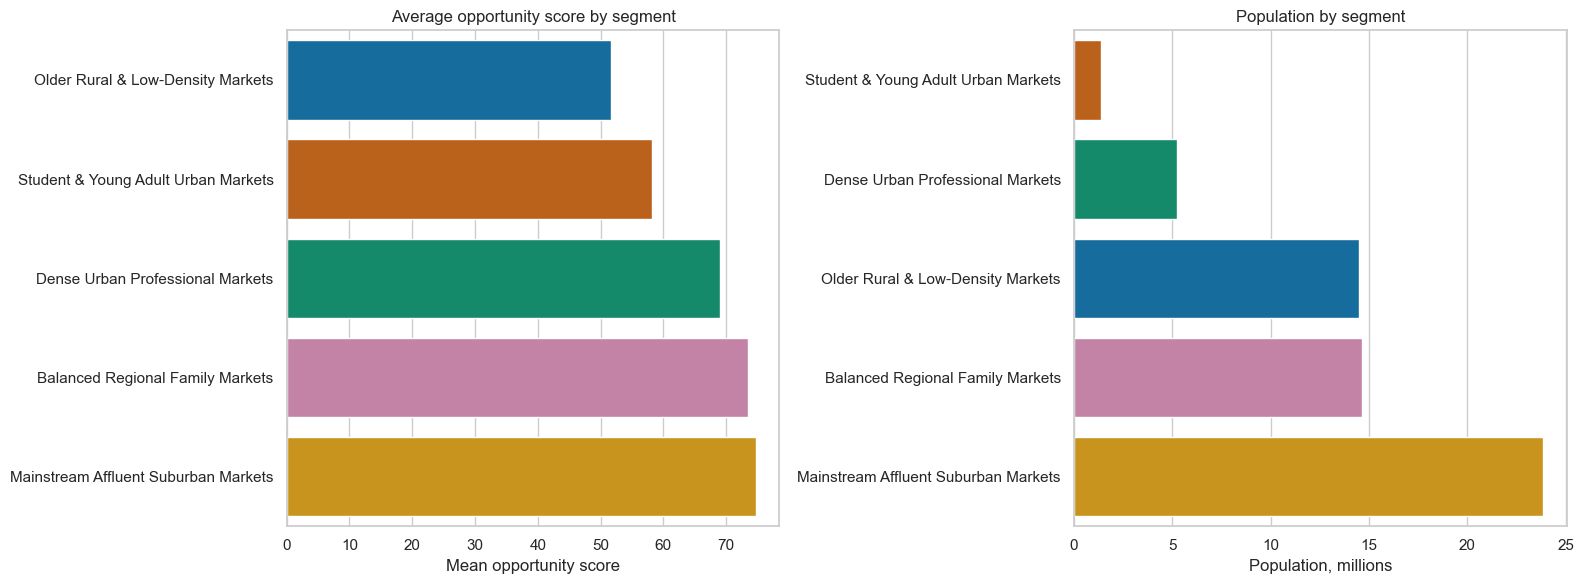

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_plot = segment_opportunity_summary.sort_values("mean_opportunity_score", ascending=True)
segment_palette = dict(zip(segment_plot["segment_label"], PALETTE[: len(segment_plot)]))
sns.barplot(
    data=segment_plot,
    x="mean_opportunity_score",
    y="segment_label",
    hue="segment_label",
    palette=segment_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Average opportunity score by segment")
axes[0].set_xlabel("Mean opportunity score")
axes[0].set_ylabel("")

sns.barplot(
    data=segment_opportunity_summary.sort_values("population_millions", ascending=True),
    x="population_millions",
    y="segment_label",
    hue="segment_label",
    palette=segment_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Population by segment")
axes[1].set_xlabel("Population, millions")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


### Insight Interpretation for the Business Slide

Given the stated commercial priority weighting, the strongest opportunities concentrate in family/suburban markets. Mainstream Affluent Suburban Markets and Balanced Regional Family Markets should be the core audience for the first wave of media investment when stakeholders filter to the highest-ranked MSOAs in the dashboard.

The most attractive places are not single isolated MSOAs; they form practical local clusters. The area table can be translated directly into regional media buying, CRM tests and attraction-specific campaign planning.

At attraction level, the strongest activation opportunities are concentrated around specific family propositions such as LEGOLAND Windsor Resort, SEA LIFE Manchester, Shrek's Adventure! London, Chessington World of Adventures Resort, SEA LIFE Birmingham and Cadbury World. This is the better level for campaign planning because it avoids overstating SEA LIFE purely because there are multiple SEA LIFE locations in the dataset.

At category level, the strategic story is still useful: Family Discovery Attraction and Family Theme Park propositions account for much of the aligned audience. Use the category roll-up to explain the type of proposition Merlin should prioritise, and the attraction-level table to decide where to activate.

Urban icon and young-adult propositions still matter, but they should be treated as more selective activation types. They work best where proximity and city context are strong, rather than as the main nationwide opportunity engine.


### 6.5 What Should Merlin Activate First?

In [15]:
family_segments = ["Mainstream Affluent Suburban Markets", "Balanced Regional Family Markets"]
family_population = int(scored.loc[scored["segment_label"].isin(family_segments), "total_population"].sum())
family_population_share = family_population / scored["total_population"].sum()

cluster_msoas = int(scored["cluster_marketing_flag"].sum())
annual_pass_msoas = int(scored["annual_pass_repeat_visit_flag"].sum())
short_break_msoas = int(scored["short_break_opportunity_flag"].sum())

cluster_population = int(scored.loc[scored["cluster_marketing_flag"], "total_population"].sum())
annual_pass_population = int(scored.loc[scored["annual_pass_repeat_visit_flag"], "total_population"].sum())
short_break_population = int(scored.loc[scored["short_break_opportunity_flag"], "total_population"].sum())

activation_recommendations = pd.DataFrame(
    [
        {
            "target_opportunity": "Family-led suburban and regional markets",
            "evidence": f"The two strongest family/suburban segments contain {family_population / 1_000_000:.1f}m people ({family_population_share:.0%} of the scored population).",
            "recommended_merlin_focus": "LEGOLAND, Chessington, SEA LIFE, Shrek's Adventure and Cadbury World",
            "recommended_activation": "Prioritise annual pass, family day-out and short-break messaging around the highest-ranked area clusters in the dashboard.",
        },
        {
            "target_opportunity": "Multi-attraction cluster markets",
            "evidence": f"{cluster_msoas:,} MSOAs ({cluster_population / 1_000_000:.1f}m people) have at least two Merlin attractions within 30 miles.",
            "recommended_merlin_focus": "Clustered portfolios and nearby attraction combinations",
            "recommended_activation": "Use cross-sell, CRM, annual pass and bundle messaging where multiple attractions are accessible.",
        },
        {
            "target_opportunity": "Annual pass markets",
            "evidence": f"{annual_pass_msoas:,} MSOAs ({annual_pass_population / 1_000_000:.1f}m people) are within 30 miles of the recommended attraction.",
            "recommended_merlin_focus": "Attractions with strong local catchments",
            "recommended_activation": "Promote annual pass value and in-attraction lifetime-value upsell opportunities.",
        },
        {
            "target_opportunity": "Short-break markets",
            "evidence": f"{short_break_msoas:,} MSOAs ({short_break_population / 1_000_000:.1f}m people) meet the family/affluence and overnight-distance rules.",
            "recommended_merlin_focus": "Resort, theme park and heritage-led destination trips",
            "recommended_activation": "Promote overnight stays, packages and premium family occasions where distance supports a short break.",
        },
    ]
)

activation_recommendations


,target_opportunity,evidence,recommended_merlin_focus,recommended_activation
0,Family-led suburban and regional markets,The two strongest family/suburban segments contain 38.5m people (65% of the scored population).,"LEGOLAND, Chessington, SEA LIFE, Shrek's Adventure and Cadbury World","Prioritise annual pass, family day-out and short-break messaging around the highest-ranked area clusters in the dashboard."
1,Multi-attraction cluster markets,"2,760 MSOAs (23.1m people) have at least two Merlin attractions within 30 miles.",Clustered portfolios and nearby attraction combinations,"Use cross-sell, CRM, annual pass and bundle messaging where multiple attractions are accessible."
2,Annual pass markets,"3,498 MSOAs (29.0m people) are within 30 miles of the recommended attraction.",Attractions with strong local catchments,Promote annual pass value and in-attraction lifetime-value upsell opportunities.
3,Short-break markets,277 MSOAs (2.4m people) meet the family/affluence and overnight-distance rules.,"Resort, theme park and heritage-led destination trips","Promote overnight stays, packages and premium family occasions where distance supports a short break."


## 7. Export Opportunity Outputs

Keep the export set deliberately small. The notebook writes only the files most useful for handover and interview submission:

- `merlin_key_recommendation_output.csv`: concise recommendation output with the key fields requested for decision-making
- `msoa_layer_2_opportunity_scores.csv`: full scored MSOA dataset for audit, modelling detail, dashboarding, and future opportunity scoring


In [16]:
output_columns = [
    "geo_code",
    "geo_name",
    "country",
    "latitude",
    "longitude",
    "segment_id",
    "segment_label",
    "overall_opportunity_score",
    "opportunity_rank",
    "opportunity_percentile",
    "market_size_score",
    "segment_priority_score",
    "recommended_attraction_alignment_score",
    "segment_category_fit_score",
    "recommended_attraction_focus",
    "recommended_attraction_name",
    "recommended_attraction_brand",
    "recommended_attraction_category",
    "recommended_attraction_distance_miles",
    "nearest_merlin_attraction",
    "nearest_merlin_brand",
    "nearest_merlin_category",
    "nearest_merlin_distance_miles",
    "recommended_activation_type",
    "activation_type_rationale",
    "recommended_activation",
    "annual_pass_repeat_visit_flag",
    "cluster_marketing_flag",
    "short_break_opportunity_flag",
    "merlin_attractions_within_30_miles",
    "merlin_attraction_cluster_names_30_miles",
    "key_contributing_driver",
    "assumptions_flag",
    "total_population",
    "children_count_0_14",
    "young_adult_count_15_24",
    "core_family_adult_count_25_44",
    "midlife_adult_count_45_64",
    "older_adult_count_65_plus",
    "total_households",
    "households_with_dependent_children",
    "households_deprived",
    "households_not_deprived",
    "households_no_car_or_van",
    "households_with_car_or_van",
    "residents_social_grade_ab_c1",
    "children_share_0_14",
    "young_adult_share_15_24",
    "core_family_adult_share_25_44",
    "midlife_adult_share_45_64",
    "older_adult_share_65_plus",
    "family_household_share",
    "deprived_household_share",
    "not_deprived_household_share",
    "car_access_household_share",
    "population_density_per_sq_km",
    "ab_c1_social_grade_share",
]

opportunity_export = scored[output_columns].copy().sort_values("opportunity_rank")

key_recommendation_columns = [
    "geo_code",
    "geo_name",
    "latitude",
    "longitude",
    "segment_id",
    "segment_label",
    "overall_opportunity_score",
    "opportunity_rank",
    "key_contributing_driver",
    "recommended_attraction_name",
    "recommended_activation_type",
]
key_recommendation_output = opportunity_export[key_recommendation_columns].copy()

opportunity_export.to_csv(OPPORTUNITY_OUTPUT_PATH, index=False)
key_recommendation_output.to_csv(KEY_RECOMMENDATION_OUTPUT_PATH, index=False)

print(f"Saved full MSOA opportunity output: {OPPORTUNITY_OUTPUT_PATH} ({opportunity_export.shape[0]:,} rows)")
print(f"Saved key recommendation output: {KEY_RECOMMENDATION_OUTPUT_PATH} ({key_recommendation_output.shape[0]:,} rows)")

key_recommendation_output.head(10)


Saved full MSOA opportunity output: /Users/ChanB01/GitHub/uk-demographic-clustering/data/output/msoa_layer_2_opportunity_scores.csv (7,264 rows)
Saved key recommendation output: /Users/ChanB01/GitHub/uk-demographic-clustering/data/output/merlin_key_recommendation_output.csv (7,264 rows)


,geo_code,geo_name,latitude,longitude,segment_id,segment_label,overall_opportunity_score,opportunity_rank,key_contributing_driver,recommended_attraction_name,recommended_activation_type
3203,E02003353,Bracknell Forest 002,51.43602,-0.763020,4,Mainstream Affluent Suburban Markets,97.7,1,large local market,LEGOLAND Windsor Resort,Multi-attraction cluster marketing
569,E02000601,Kingston upon Thames 004,51.41714,-0.298440,4,Mainstream Affluent Suburban Markets,97.6,2,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing
6585,E02006837,Epsom and Ewell 010,51.34441,-0.238040,4,Mainstream Affluent Suburban Markets,97.6,3,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing
3298,E02003450,Wokingham 012,51.41607,-0.937690,4,Mainstream Affluent Suburban Markets,97.5,4,large local market,LEGOLAND Windsor Resort,Multi-attraction cluster marketing
6154,E02006399,Runnymede 007,51.37477,-0.503170,4,Mainstream Affluent Suburban Markets,97.5,5,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing
6628,E02006882,Harrow 033,51.59156,-0.313320,4,Mainstream Affluent Suburban Markets,97.3,6,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing
6668,E02006925,Redbridge 036,51.58409,0.053548,4,Mainstream Affluent Suburban Markets,97.3,7,large local market,Shrek's Adventure! London,Multi-attraction cluster marketing
741,E02000787,Richmond upon Thames 004,51.46775,-0.285110,4,Mainstream Affluent Suburban Markets,97.2,8,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing
3529,E02003688,Buckinghamshire 053,51.60788,-0.637940,4,Mainstream Affluent Suburban Markets,97.1,9,large local market,LEGOLAND Windsor Resort,Multi-attraction cluster marketing
5001,E02005204,Fylde 002,53.78466,-2.897340,4,Mainstream Affluent Suburban Markets,96.9,10,large local market,SEA LIFE Blackpool,Annual pass


## 8. Assumptions, Limitations and Next Steps

This opportunity score should be presented as a prioritisation index, not a demand forecast. It is designed to rank where Merlin should investigate, test and activate first.

Main assumptions and limitations:

- The score uses public demographic and geographic data only. It does not include Merlin bookings, passholder records, CRM engagement, ticket yield, media spend, web demand or historic conversion.
- Segment priority and attraction-category fit are judgement-based. They are intentionally simple for stakeholder communication, but should be calibrated with Merlin customer and revenue data when available.
- Distance is measured from MSOA centroid to attraction coordinates using straight-line geography. A production version should use drive time, public transport time and catchment overlap.
- AB/C1 share, deprivation and household composition are useful proxies, but they are not the same as disposable income, leisure intent or actual propensity to visit Merlin.
- Competitor attractions, tourism flows, accommodation supply, school-holiday timing and local media costs are not included. These could change the commercial priority of some areas.
- The recommended attraction is the best modelled Merlin proposition for that MSOA, after combining segment-category fit and distance to that specific attraction. It is not necessarily the nearest Merlin attraction.

Recommended next stage:

Use this output as a shortlist for validation. The most valuable next step would be to overlay internal Merlin customer penetration, revenue, product ownership, campaign response and drive-time data. That would turn this public-data opportunity index into a calibrated growth and media-prioritisation model.